# It is slow and nobody knows where

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/latency-budget/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/latency-budget/demo.ipynb)

A RAG request walks five hops: gateway, query embedding, vector search fanned out to 8 shards, reranker, LLM. Each
hop has a dashboard with p50, p95 and p99. This notebook declares each hop's latency (a lognormal body plus the one
tail mechanism it really has), computes the end-to-end distribution EXACTLY on a 1 ms grid, and asks three
questions the per-hop dashboards answer wrongly: is the chain over its SLO, which hop owns the slow requests, and
which fix to fund.

1. The engine
2. Calibration - exact vs simulation
3. Percentiles do not add
4. Fan-out: every shard is healthy, the step is not
5. Who owns the average vs who owns the tail
6. Five fixes, ranked two ways
7. The chart
8. Try your own

## 1. The engine

Extracted from `latency.py` at build time. Sequential hops convolve; a fan-out step is the max of 8 shards, so
its CDF is the shard CDF to the 8th power; a hedged call is a min, so survivals multiply; a timeout-and-retry is
a mixture of the body and (timeout + a fresh body).

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np

SEED = 194


MC_REPS = 200_000


GRID_MS = 8_000


SHARDS = 8


SLO_MS = 1_500


PCTS = (0.50, 0.95, 0.99)


HOPS = ("gateway", "embed", "search", "rerank", "llm")


BASE: Dict[str, float] = {
    "gateway_median": 8.0, "gateway_sigma": 0.30,
    "embed_median": 25.0, "embed_sigma": 0.25, "embed_cold_p": 0.02, "embed_cold_ms": 300.0,
    "shard_median": 30.0, "shard_sigma": 0.35, "shard_gc_p": 0.008, "shard_gc_ms": 250.0, "hedge_after_ms": 0.0,
    "rerank_median": 60.0, "rerank_sigma": 0.30, "rerank_hang_p": 0.03, "rerank_timeout_ms": 400.0,
    "llm_median": 900.0, "llm_sigma": 0.12,
}


FIXES: Dict[str, Dict[str, float]] = {
    "smaller LLM (-15% median)": {"llm_median": 765.0},
    "warm embedding pool": {"embed_cold_p": 0.0},
    "hedge shard calls at 80 ms": {"hedge_after_ms": 80.0},
    "rerank timeout 400 -> 120 ms": {"rerank_timeout_ms": 120.0},
    "all three config fixes": {"embed_cold_p": 0.0, "hedge_after_ms": 80.0, "rerank_timeout_ms": 120.0},
}


def _erf(x: np.ndarray) -> np.ndarray:
    return np.frompyfunc(math.erf, 1, 1)(x).astype(float)


def lognormal_pmf(median: float, sigma: float, n: int = GRID_MS) -> np.ndarray:
    """Mass on integer ms k = P(k - 0.5 < X <= k + 0.5): the grid rounds to the nearest millisecond."""
    edges = np.arange(n + 1) - 0.5
    pos = np.clip(edges, 1e-12, None)
    cdf = 0.5 * (1.0 + _erf(np.log(pos / median) / (sigma * math.sqrt(2.0))))
    cdf[edges <= 0] = 0.0
    p = np.diff(cdf)
    p[-1] += 1.0 - cdf[-1]
    return p


def shift(p: np.ndarray, ms: float) -> np.ndarray:
    k = int(round(ms))
    if k <= 0:
        return p.copy()
    out = np.zeros_like(p)
    out[k:] = p[:-k]
    out[-1] += p[-k:].sum()
    return out


def conv(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    full = np.convolve(a, b)
    out = full[: len(a)].copy()
    out[-1] += full[len(a):].sum()
    return out


def cdf_of(p: np.ndarray) -> np.ndarray:
    return np.minimum(np.cumsum(p), 1.0)


def from_cdf(c: np.ndarray) -> np.ndarray:
    return np.diff(np.concatenate([[0.0], c]))


def shard_pmf(prm: Dict[str, float]) -> np.ndarray:
    """One shard: lognormal body, plus a GC pause with probability shard_gc_p. Hedged if hedge_after_ms > 0."""
    body = lognormal_pmf(prm["shard_median"], prm["shard_sigma"])
    one = (1 - prm["shard_gc_p"]) * body + prm["shard_gc_p"] * shift(body, prm["shard_gc_ms"])
    h = prm["hedge_after_ms"]
    if h > 0:
        surv = 1.0 - cdf_of(one)
        surv_copy = 1.0 - cdf_of(shift(one, h))
        one = from_cdf(1.0 - surv * surv_copy)
    return one


def hop_pmfs(prm: Dict[str, float]) -> Dict[str, np.ndarray]:
    g = lognormal_pmf(prm["gateway_median"], prm["gateway_sigma"])
    e_body = lognormal_pmf(prm["embed_median"], prm["embed_sigma"])
    e = (1 - prm["embed_cold_p"]) * e_body + prm["embed_cold_p"] * shift(e_body, prm["embed_cold_ms"])
    s = from_cdf(cdf_of(shard_pmf(prm)) ** SHARDS)
    r_body = lognormal_pmf(prm["rerank_median"], prm["rerank_sigma"])
    tau = int(round(prm["rerank_timeout_ms"]))
    h = prm["rerank_hang_p"]
    kept = r_body.copy()
    kept[tau + 1:] = 0.0
    p_retry = h + (1 - h) * r_body[tau + 1:].sum()
    r = (1 - h) * kept + p_retry * shift(r_body, tau)
    llm = lognormal_pmf(prm["llm_median"], prm["llm_sigma"])
    return {"gateway": g, "embed": e, "search": s, "rerank": r, "llm": llm}


def chain(pmfs: Dict[str, np.ndarray], skip: Optional[str] = None) -> np.ndarray:
    out: Optional[np.ndarray] = None
    for k in HOPS:
        if k == skip:
            continue
        out = pmfs[k] if out is None else conv(out, pmfs[k])
    assert out is not None
    return out


def percentile(p: np.ndarray, q: float) -> int:
    return int(np.searchsorted(cdf_of(p), q - 1e-12))


def mean(p: np.ndarray) -> float:
    return float(np.dot(np.arange(len(p)), p))


def summary(p: np.ndarray) -> Dict[str, float]:
    out = {f"p{int(q * 100)}": percentile(p, q) for q in PCTS}
    out["mean"] = mean(p)
    return out


def tail_attribution(pmfs: Dict[str, np.ndarray], t: int) -> Dict[str, float]:
    """E[X_i | T > t] - E[X_i] for each hop: how much MORE of hop i a slow request carries. Sums exactly to
    E[T | T > t] - E[T], because sum_i X_i = T.

    E[X_i 1{T>t}] = sum_x x p_i(x) P(T_-i > t - x), with T_-i the chain without hop i.
    """
    total = chain(pmfs)
    p_tail = float(total[t + 1:].sum())
    ks = np.arange(GRID_MS)
    out: Dict[str, float] = {}
    for h in HOPS:
        others_cdf = cdf_of(chain(pmfs, skip=h))
        need = t - ks
        surv = np.where(need < 0, 1.0, 1.0 - others_cdf[np.clip(need, 0, GRID_MS - 1)])
        out[h] = float(np.dot(ks * pmfs[h], surv)) / p_tail - mean(pmfs[h])
    return out


def study(prm: Optional[Dict[str, float]] = None) -> Dict[str, object]:
    prm = dict(BASE if prm is None else prm)
    pm = hop_pmfs(prm)
    total = chain(pm)
    hops = {h: summary(pm[h]) for h in HOPS}
    e2e = summary(total)
    shard = summary(shard_pmf(prm))
    q99 = int(e2e["p99"])
    excess = tail_attribution(pm, q99)
    mean_share = {h: hops[h]["mean"] / e2e["mean"] for h in HOPS}
    excess_total = sum(excess.values())
    return {
        "hops": hops, "e2e": e2e, "shard": shard,
        "sum_of_hop_p99": sum(hops[h]["p99"] for h in HOPS),
        "sum_of_hop_p50": sum(hops[h]["p50"] for h in HOPS),
        "p_over_slo": float(total[SLO_MS + 1:].sum()),
        "p_any_shard_gc": 1 - (1 - prm["shard_gc_p"]) ** SHARDS,
        "mean_share": mean_share,
        "tail_excess_ms": excess,
        "tail_share": {h: excess[h] / excess_total for h in HOPS},
        "p_tail": float(total[q99 + 1:].sum()),
    }


def fix_table(base: Optional[Dict[str, float]] = None) -> List[Dict[str, object]]:
    base = dict(BASE if base is None else base)
    ref = study(base)
    rows = []
    for name, change in FIXES.items():
        s = study({**base, **change})
        rows.append({
            "fix": name,
            "d_mean": s["e2e"]["mean"] - ref["e2e"]["mean"],
            "d_p50": s["e2e"]["p50"] - ref["e2e"]["p50"],
            "d_p99": s["e2e"]["p99"] - ref["e2e"]["p99"],
            "p_over_slo": s["p_over_slo"],
            "p99": s["e2e"]["p99"],
        })
    return rows


def simulate(prm: Optional[Dict[str, float]] = None, n: int = MC_REPS, seed: int = SEED) -> Dict[str, np.ndarray]:
    """The same model drawn continuously, rounded to the nearest ms at the end of each hop."""
    prm = dict(BASE if prm is None else prm)
    rng = np.random.default_rng(seed)

    def ln(med: float, sig: float, size: Tuple[int, ...]) -> np.ndarray:
        return med * np.exp(sig * rng.standard_normal(size))

    g = ln(prm["gateway_median"], prm["gateway_sigma"], (n,))
    e = ln(prm["embed_median"], prm["embed_sigma"], (n,)) + prm["embed_cold_ms"] * (rng.random(n) < prm["embed_cold_p"])
    sh = ln(prm["shard_median"], prm["shard_sigma"], (n, SHARDS)) + prm["shard_gc_ms"] * (rng.random((n, SHARDS)) < prm["shard_gc_p"])
    sh = np.rint(sh)
    if prm["hedge_after_ms"] > 0:
        copy = ln(prm["shard_median"], prm["shard_sigma"], (n, SHARDS)) + prm["shard_gc_ms"] * (rng.random((n, SHARDS)) < prm["shard_gc_p"])
        sh = np.minimum(sh, np.rint(copy) + round(prm["hedge_after_ms"]))
    s = sh.max(axis=1)
    tau = round(prm["rerank_timeout_ms"])
    r1 = np.rint(ln(prm["rerank_median"], prm["rerank_sigma"], (n,)))
    hang = rng.random(n) < prm["rerank_hang_p"]
    r2 = np.rint(ln(prm["rerank_median"], prm["rerank_sigma"], (n,)))
    r = np.where(hang | (r1 > tau), tau + r2, r1)
    llm = ln(prm["llm_median"], prm["llm_sigma"], (n,))
    hops = {"gateway": np.rint(g), "embed": np.rint(e), "search": s, "rerank": r, "llm": np.rint(llm)}
    hops["total"] = sum(hops[h] for h in HOPS)
    return hops


def wilson(k: int, n: int, z: float = 2.576) -> Tuple[float, float]:
    if n == 0:
        return (0.0, 1.0)
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    w = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (c - w, c + w)


def calibrate(n: int = MC_REPS, seed: int = SEED) -> List[Dict[str, object]]:
    """Exact P(T > t) against Monte Carlo, at the thresholds the study quotes, for the base chain and each fix."""
    rows = []
    for label, prm in [("base", dict(BASE))] + [(k, {**BASE, **v}) for k, v in FIXES.items()]:
        total = chain(hop_pmfs(prm))
        sim = simulate(prm, n, seed)["total"]
        for t in (summary(total)["p95"], summary(total)["p99"], SLO_MS):
            exact = float(total[int(t) + 1:].sum())
            k = int((sim > t).sum())
            lo, hi = wilson(k, n)
            rows.append({"chain": label, "t": int(t), "exact": exact, "mc": k / n, "inside": lo <= exact <= hi})
    return rows


def parse_params(text: str) -> Dict[str, float]:
    """`key=value, key=value` overrides on BASE. Unknown keys and negative values are refused, not ignored."""
    prm = dict(BASE)
    for part in [x.strip() for x in text.split(",") if x.strip()]:
        if "=" not in part:
            raise ValueError(f"'{part}' is not key=value")
        k, v = (s.strip() for s in part.split("=", 1))
        if k not in BASE:
            raise ValueError(f"unknown parameter '{k}'")
        val = float(v)
        if val < 0 or (k.endswith("_p") and val > 1):
            raise ValueError(f"{k}={v} is out of range")
        prm[k] = val
    return prm

## 2. Calibration - exact vs simulation

`simulate` draws the same model continuously and rounds each hop to the nearest ms (the grid's own convention).
Each exact tail probability P(T > t) should sit inside the 99% Wilson interval of the simulated share.

**Resolution of the instrument.** The study in `evidence.txt` uses 200,000 simulated requests; this notebook
uses 20,000 to run in seconds, so its intervals are about 3x wider and it can flag a different cell than the
study does. The exact numbers below do not depend on this.

In [2]:
cal = calibrate(n=20000, seed=SEED)
for r in cal:
    print(f"{r['chain']:<30} t={r['t']:>5}  exact {r['exact']:.5f}  mc {r['mc']:.5f}  {'ok' if r['inside'] else 'OUTSIDE'}")
print(f"{sum(r['inside'] for r in cal)}/{len(cal)} inside")

base                           t= 1371  exact 0.04995  mc 0.05090  ok
base                           t= 1551  exact 0.00993  mc 0.01030  ok
base                           t= 1500  exact 0.01641  mc 0.01675  ok
smaller LLM (-15% median)      t= 1223  exact 0.04996  mc 0.05065  ok
smaller LLM (-15% median)      t= 1397  exact 0.00992  mc 0.01020  ok
smaller LLM (-15% median)      t= 1500  exact 0.00328  mc 0.00335  ok
warm embedding pool            t= 1348  exact 0.04972  mc 0.05000  ok
warm embedding pool            t= 1529  exact 0.00997  mc 0.00975  ok
warm embedding pool            t= 1500  exact 0.01334  mc 0.01315  ok
hedge shard calls at 80 ms     t= 1333  exact 0.04977  mc 0.04875  ok
hedge shard calls at 80 ms     t= 1526  exact 0.00990  mc 0.00995  ok
hedge shard calls at 80 ms     t= 1500  exact 0.01295  mc 0.01280  ok
rerank timeout 400 -> 120 ms   t= 1324  exact 0.04964  mc 0.04985  ok
rerank timeout 400 -> 120 ms   t= 1462  exact 0.00993  mc 0.01050  ok
rerank timeout 400 -

## 3. Percentiles do not add

The tempting budget: each hop owns a p99 budget, and the budgets add to the SLO. But a request that is slow in
the reranker is almost never also slow in the embedder, so the end-to-end p99 is far below the sum of hop p99s.

In [3]:
s = study()
print(f"{'hop':<10} {'p50':>6} {'p95':>6} {'p99':>6} {'mean':>8} {'p99/p50':>8}")
for h in HOPS:
    r = s["hops"][h]
    print(f"{h:<10} {r['p50']:>6} {r['p95']:>6} {r['p99']:>6} {r['mean']:>8.1f} {r['p99'] / r['p50']:>8.1f}")
e = s["e2e"]
print(f"{'END-TO-END':<10} {e['p50']:>6} {e['p95']:>6} {e['p99']:>6} {e['mean']:>8.1f}")
print(f"sum of per-hop p99 = {s['sum_of_hop_p99']} ms vs true p99 {e['p99']} ms  (overstates by {s['sum_of_hop_p99'] - e['p99']} ms)")
print(f"SLO p99 <= {SLO_MS} ms: per-hop sum says {s['sum_of_hop_p99'] - SLO_MS} ms over; truth {e['p99'] - SLO_MS} ms over, P(T > SLO) = {s['p_over_slo']:.2%}")

hop           p50    p95    p99     mean  p99/p50
gateway         8     13     16      8.4      2.0
embed          25     40    325     31.8     13.0
search         50    272    293     65.0      5.9
rerank         61    111    468     74.8      7.7
llm           900   1096   1190    906.5      1.3
END-TO-END   1064   1371   1551   1086.4
sum of per-hop p99 = 2292 ms vs true p99 1551 ms  (overstates by 741 ms)
SLO p99 <= 1500 ms: per-hop sum says 792 ms over; truth 51 ms over, P(T > SLO) = 1.64%


## 4. Fan-out: every shard is healthy, the step is not

One shard pauses for GC 0.8% of the time, below its own p99, so every shard dashboard is clean. The search step
waits for the slowest of 8, so it meets a pause on 1 - 0.992^8 of requests.

In [4]:
print(f"one shard p99 = {s['shard']['p99']} ms")
print(f"P(some shard pauses) = {s['p_any_shard_gc']:.1%}, search step p95 = {s['hops']['search']['p95']} ms")

one shard p99 = 82 ms
P(some shard pauses) = 6.2%, search step p95 = 272 ms


## 5. Who owns the average vs who owns the tail

Mean share is what a latency breakdown chart shows. Tail excess is E[hop | request slower than p99] - E[hop]:
how much MORE of each hop a slow request carries. It is exact (one convolution per hop) and the five excesses sum
to E[T | slow] - E[T]. The hop with the worst p99/p50 ratio (embedding, 13x) is a third answer.

In [5]:
print(f"{'hop':<10} {'mean share':>11} {'tail excess ms':>15} {'tail share':>11}")
for h in HOPS:
    print(f"{h:<10} {s['mean_share'][h]:>11.1%} {s['tail_excess_ms'][h]:>15.1f} {s['tail_share'][h]:>11.1%}")

hop         mean share  tail excess ms  tail share
gateway           0.8%             0.1        0.0%
embed             2.9%            60.0       10.7%
search            6.0%            63.5       11.4%
rerank            6.9%           288.1       51.6%
llm              83.4%           146.5       26.2%


## 6. Five fixes, ranked two ways

A smaller LLM, a warm embedding pool, hedged shard calls, a shorter reranker timeout, and the three config
changes together. The mean ranks the LLM first by 5.6x; the p99 and the SLO rank the three config changes first.

In [6]:
fixes = fix_table()
print(f"{'fix':<30} {'d mean':>8} {'d p50':>6} {'d p99':>6} {'p99':>6} {'P(T>SLO)':>9}")
for r in fixes:
    print(f"{r['fix']:<30} {r['d_mean']:>+8.1f} {r['d_p50']:>+6} {r['d_p99']:>+6} {r['p99']:>6} {r['p_over_slo']:>9.2%}")

fix                              d mean  d p50  d p99    p99  P(T>SLO)
smaller LLM (-15% median)        -136.0   -137   -154   1397     0.33%
warm embedding pool                -6.0     -3    -22   1529     1.33%
hedge shard calls at 80 ms        -10.5     -5    -25   1526     1.30%
rerank timeout 400 -> 120 ms       -7.9     -1    -89   1462     0.61%
all three config fixes            -24.4     -9   -190   1361     0.07%


## 7. The chart

The full audit figure is `latency_audit.png` (built by `make_chart.py` from `results.json`). Here, the
end-to-end distribution before and after the two candidate investments.

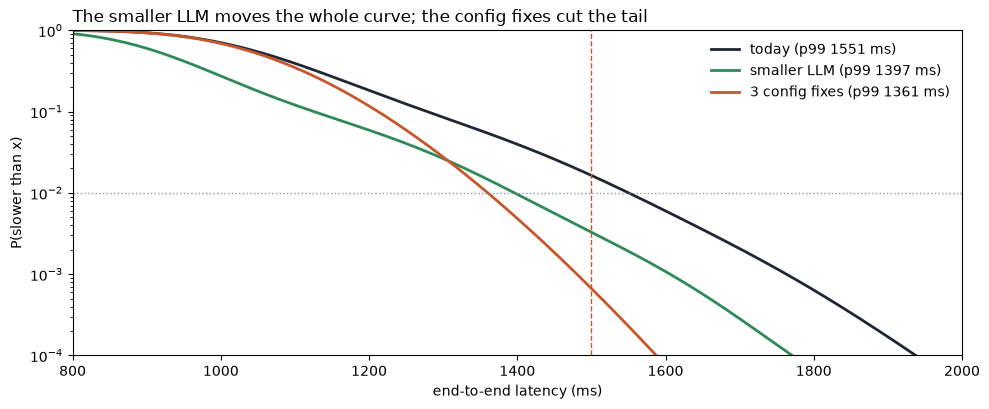

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.2))
for label, prm, col in [("today", BASE, "#1f2733"),
                        ("smaller LLM", {**BASE, **FIXES["smaller LLM (-15% median)"]}, "#2e8b57"),
                        ("3 config fixes", {**BASE, **FIXES["all three config fixes"]}, "#c8562b")]:
    p = chain(hop_pmfs(prm))
    surv = 1 - np.cumsum(p)
    ax.semilogy(np.arange(len(p)), np.clip(surv, 1e-6, 1), color=col, lw=2, label=f"{label} (p99 {percentile(p, 0.99)} ms)")
ax.axvline(SLO_MS, color="#c8562b", ls="--", lw=1)
ax.axhline(0.01, color="#8a94a3", ls=":", lw=1)
ax.set_xlim(800, 2000)
ax.set_ylim(1e-4, 1)
ax.set_xlabel("end-to-end latency (ms)")
ax.set_ylabel("P(slower than x)")
ax.set_title("The smaller LLM moves the whole curve; the config fixes cut the tail", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("notebook_chart.png", dpi=120)
plt.show()

## Summary

- Adding per-hop p99s says the chain is 792 ms over a 1,500 ms SLO. It is 51 ms over.
- Every shard's p99 is 82 ms; the search step's p95 is 272 ms, because 8 shards meet a 0.8% pause 6.2% of the time.
- The LLM is 83% of the average and 26% of the tail excess; the reranker's hang-and-retry is 7% and 52%.
- Three config changes save 24 ms of mean and 190 ms of p99. A 15% smaller LLM saves 136 ms of mean and 154 ms
  of p99. A mean dashboard funds the LLM; the SLO wants the config changes (0.07% vs 0.33% of requests over).
- Negative result: on its own, no single config fix beats the smaller LLM on p99. The win needs all three.

## 8. Try your own

In [8]:
# Override any BASE parameter, e.g. your reranker never hangs but your LLM is spikier:
# mine = parse_params("rerank_hang_p=0.0, llm_sigma=0.3")
# print(study(mine)["e2e"], study(mine)["tail_share"])
# for r in fix_table(mine): print(r["fix"], round(r["d_mean"]), r["d_p99"])

---
Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder). The Streamlit version takes your
own hop parameters: `pip install -r requirements.txt && streamlit run app.py`.

Sibling builds: [`llm-router`](../llm-router) and [`semantic-cache`](../semantic-cache) are serving-path tools
that change latency; this build says where a latency budget is actually spent.
[`context-packing`](../context-packing) is an earlier audit of a metric that ranked the fixes backwards.